In [1]:
#load the three tables
import pandas as pd

df1 = pd.read_csv("schema_1_ontario_final.csv")
df2 = pd.read_csv("schema_2_ontario_final.csv")
df3 = pd.read_csv("schema_3_ontario_final.csv")

In [2]:
#printing all column names
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['week', 'fsa', 'probable', 'vulnerable', 'is_most_recent',
       'fever_chills_shakes', 'cough', 'shortness_of_breath', 'over_60',
       'any_medical_conditions', 'travel_outside_canada',
       'contact_with_illness'],
      dtype='object')
Index(['week', 'fsa', 'probable', 'vulnerable', 'is_most_recent',
       'fever_chills_shakes', 'cough', 'shortness_of_breath',
       'any_medical_conditions', 'travel_outside_canada',
       'contact_with_illness', 'symptoms', 'conditions', 'ethnicity', 'sex',
       'needs', 'age_1'],
      dtype='object')
Index(['month', 'fsa', 'probable', 'vulnerable', 'fever_chills_shakes',
       'cough', 'shortness_of_breath', 'any_medical_conditions',
       'travel_outside_canada', 'contact_with_illness', 'contact_in_household',
       'tested', 'covid_results_date', 'covid_positive', 'symptoms',
       'conditions', 'ethnicity', 'sex', 'needs', 'age_1',
       'mental_health_impact', 'travel_work_school', 'self_isolating',
       'media_channels

In [3]:
#checking about raw month values
df3['month'].astype(str).unique()[:20]


array(['April', 'May', 'June', 'July'], dtype=object)

In [4]:
#as this data belongs to 2020, creating a proper datetime column
df3['month'] = pd.to_datetime(
    '2020 ' + df3['month'].astype(str),
    format='%Y %B'
)


In [5]:
df3['month'].head()
df3['month'].dtype


dtype('<M8[ns]')

In [6]:
df3['month'].dtype == 'datetime64[ns]'


True

In [7]:
#converting month to week & keeping with year
df3['week'] = df3['month'].dt.to_period('W').astype(str)


In [8]:
df3['week'].head()

0    2020-03-30/2020-04-05
1    2020-03-30/2020-04-05
2    2020-03-30/2020-04-05
3    2020-03-30/2020-04-05
4    2020-03-30/2020-04-05
Name: week, dtype: object

In [9]:
#Creating a week_start datetime column
import pandas as pd
from datetime import datetime

# Function to convert year + week number to the first day of the week (Monday)
def week_start_date(year, week):
    return datetime.strptime(f'{year}-W{int(week)}-1', "%Y-W%W-%w")

# Assign a year column
df1['year'] = 2020
df2['year'] = 2020

# Create week_start datetime
df1['week_start'] = df1.apply(lambda x: week_start_date(x['year'], x['week']), axis=1)
df2['week_start'] = df2.apply(lambda x: week_start_date(x['year'], x['week']), axis=1)


In [10]:
df1[['week', 'year', 'week_start']].head()
df2[['week', 'year', 'week_start']].head()


,week,year,week_start
0,15,2020,2020-04-13
1,16,2020,2020-04-20
2,16,2020,2020-04-20
3,16,2020,2020-04-20
4,16,2020,2020-04-20


In [11]:
#to get common datetime column
df3['week_start'] = df3['month'].dt.to_period('W').apply(lambda r: r.start_time)


In [12]:
covid_df = pd.concat([df1, df2, df3], ignore_index=True)


In [13]:
print(covid_df.columns)



Index(['week', 'fsa', 'probable', 'vulnerable', 'is_most_recent',
       'fever_chills_shakes', 'cough', 'shortness_of_breath', 'over_60',
       'any_medical_conditions', 'travel_outside_canada',
       'contact_with_illness', 'year', 'week_start', 'symptoms', 'conditions',
       'ethnicity', 'sex', 'needs', 'age_1', 'month', 'contact_in_household',
       'tested', 'covid_results_date', 'covid_positive',
       'mental_health_impact', 'travel_work_school', 'self_isolating',
       'media_channels', 'financial_obligations_impact', 'tobacco_usage'],
      dtype='object')


In [15]:
covid_df['week_start'].head()

0   2020-03-30
1   2020-03-30
2   2020-04-06
3   2020-03-30
4   2020-03-30
Name: week_start, dtype: datetime64[ns]

In [19]:
covid_df['week_number'] = covid_df['week_start'].dt.isocalendar().week
covid_df['month'] = covid_df['week_start'].dt.month


0         3
1         3
2         4
3         3
4         3
         ..
294100    6
294101    6
294102    6
294103    6
294104    6
Name: month, Length: 294105, dtype: int32

In [21]:
covid_df.dtypes

week                                    object
fsa                                     object
probable                                object
vulnerable                              object
is_most_recent                          object
fever_chills_shakes                     object
cough                                   object
shortness_of_breath                     object
over_60                                 object
any_medical_conditions                  object
travel_outside_canada                   object
contact_with_illness                    object
year                                   float64
week_start                      datetime64[ns]
symptoms                                object
conditions                              object
ethnicity                               object
sex                                     object
needs                                   object
age_1                                   object
month                                    int32
contact_in_ho

In [22]:
#changing data types
yn_cols = [
    'probable', 'vulnerable', 'is_most_recent',
    'fever_chills_shakes', 'cough', 'shortness_of_breath',
    'over_60', 'any_medical_conditions', 'travel_outside_canada',
    'contact_with_illness', 'contact_in_household', 'tested',
    'covid_positive', 'self_isolating'
]
#mapping  Y,y ->Yes and N,n-> No
for col in yn_cols:
    if col in covid_df.columns:  # skip if column does not exist
        covid_df[col] = covid_df[col].map({'Y': 'Yes',
                                           "N": "No",
                                           "y": "Yes",
                                           "n": "No"})
        


In [24]:
#to verify the results
covid_df[yn_cols].head()
#covid_df[yn_cols].dtypes


,probable,vulnerable,is_most_recent,fever_chills_shakes,cough,shortness_of_breath,over_60,any_medical_conditions,travel_outside_canada,contact_with_illness,contact_in_household,tested,covid_positive,self_isolating
0,No,No,Yes,No,No,No,No,No,No,No,NaN,NaN,NaN,NaN
1,Yes,Yes,Yes,No,No,No,Yes,Yes,No,Yes,NaN,NaN,NaN,NaN
2,No,Yes,Yes,No,No,No,Yes,No,No,No,NaN,NaN,NaN,NaN
3,No,No,Yes,No,No,No,No,No,No,No,NaN,NaN,NaN,NaN
4,No,Yes,No,No,No,No,No,Yes,No,No,NaN,NaN,NaN,NaN


In [27]:
covid_df.dtypes

week                                    object
fsa                                     object
probable                                object
vulnerable                              object
is_most_recent                          object
fever_chills_shakes                     object
cough                                   object
shortness_of_breath                     object
over_60                                 object
any_medical_conditions                  object
travel_outside_canada                   object
contact_with_illness                    object
year                                   float64
week_start                      datetime64[ns]
symptoms                                object
conditions                              object
ethnicity                               object
sex                                     object
needs                                   object
age_1                                  float64
month                                    int32
contact_in_ho

In [28]:
# to convert object to numeric dtypes
covid_df['age_1'] = pd.to_numeric(covid_df['age_1'], errors='coerce')
covid_df['week_number'] = covid_df['week_number'].astype('Int32')  # already UInt32, optional
covid_df['month'] = covid_df['month'].astype('Int32')
covid_df.dtypes

week                                    object
fsa                                     object
probable                                object
vulnerable                              object
is_most_recent                          object
fever_chills_shakes                     object
cough                                   object
shortness_of_breath                     object
over_60                                 object
any_medical_conditions                  object
travel_outside_canada                   object
contact_with_illness                    object
year                                   float64
week_start                      datetime64[ns]
symptoms                                object
conditions                              object
ethnicity                               object
sex                                     object
needs                                   object
age_1                                  float64
month                                    Int32
contact_in_ho

In [29]:
covid_df

,week,fsa,probable,vulnerable,is_most_recent,fever_chills_shakes,cough,shortness_of_breath,over_60,any_medical_conditions,...,tested,covid_results_date,covid_positive,mental_health_impact,travel_work_school,self_isolating,media_channels,financial_obligations_impact,tobacco_usage,week_number
0,13,L4C,No,No,Yes,No,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
1,13,P1H,Yes,Yes,Yes,No,No,No,Yes,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
2,14,N2J,No,Yes,Yes,No,No,No,Yes,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15
3,13,N1G,No,No,Yes,No,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
4,13,M1P,No,Yes,No,No,No,No,No,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294100,2020-06-29/2020-07-05,M6P,No,No,NaN,No,No,No,NaN,Yes,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27
294101,2020-06-29/2020-07-05,K1R,No,No,NaN,No,No,No,NaN,Yes,...,Yes,July,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27
294102,2020-06-29/2020-07-05,M4M,No,No,NaN,No,No,No,NaN,Yes,...,Yes,July,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27
294103,2020-06-29/2020-07-05,M6P,No,Yes,NaN,No,No,No,NaN,Yes,...,No,NaN,NaN,noImpact,didntTravelBefore,No,newspaper;radio,NaN,n,27


In [37]:
covid_df[['week_number','week']]

,week_number,week
0,14,13
1,14,13
2,15,14
3,14,13
4,14,13
...,...,...
294100,27,2020-06-29/2020-07-05
294101,27,2020-06-29/2020-07-05
294102,27,2020-06-29/2020-07-05
294103,27,2020-06-29/2020-07-05


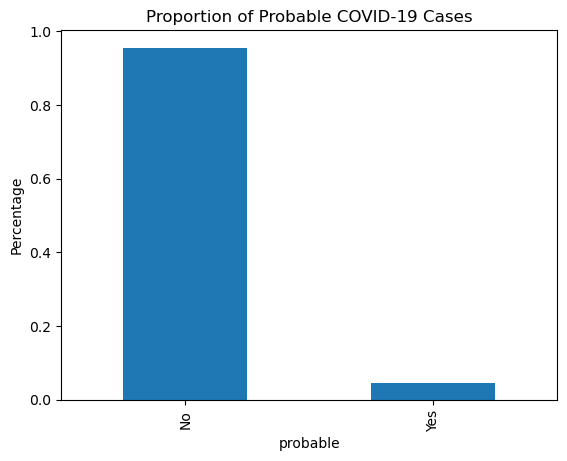

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

covid_df["probable"].value_counts(normalize=True).plot(kind="bar")
plt.title("Proportion of Probable COVID-19 Cases")
plt.ylabel("Percentage")
plt.show()


In [ ]:
symptoms = ["cough", "fever_chills_shakes", "shortness_of_breath"]

symptom_by_probable = (
    covid_df.groupby("probable")[symptoms]
      .mean()
)

symptom_by_probable.plot(kind="bar")
plt.title("Symptom Prevalence by Probable COVID Status")
plt.ylabel("Proportion")
plt.show()


In [ ]:
covid_df.groupby("contact_with_illness")["probable"].mean().plot(kind="bar")
plt.title("Probable COVID-19 by Contact with Illness")
plt.show()


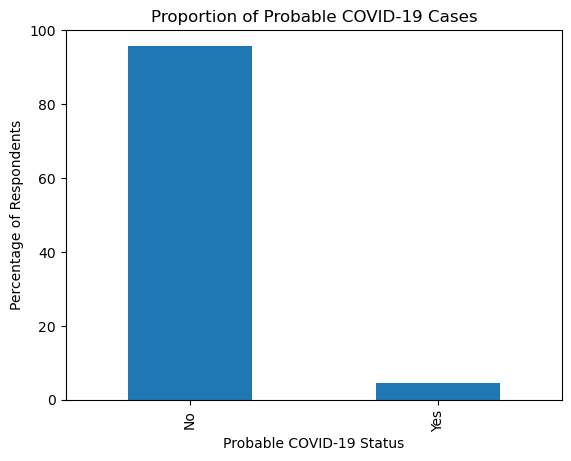

In [46]:
(covid_df["probable"]
 .value_counts(normalize=True)
 .mul(100)
 .plot(kind="bar"))

plt.title("Proportion of Probable COVID-19 Cases")
plt.ylabel("Percentage of Respondents")
plt.xlabel("Probable COVID-19 Status")
plt.ylim(0, 100)
plt.show()


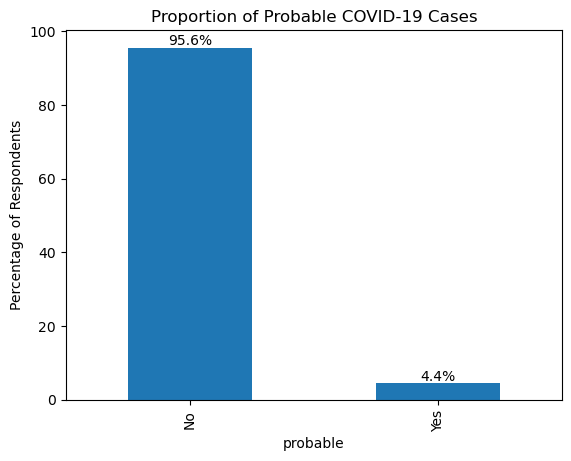

In [47]:
ax = (covid_df["probable"]
      .value_counts(normalize=True)
      .mul(100)
      .plot(kind="bar"))

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.title("Proportion of Probable COVID-19 Cases")
plt.ylabel("Percentage of Respondents")
plt.show()


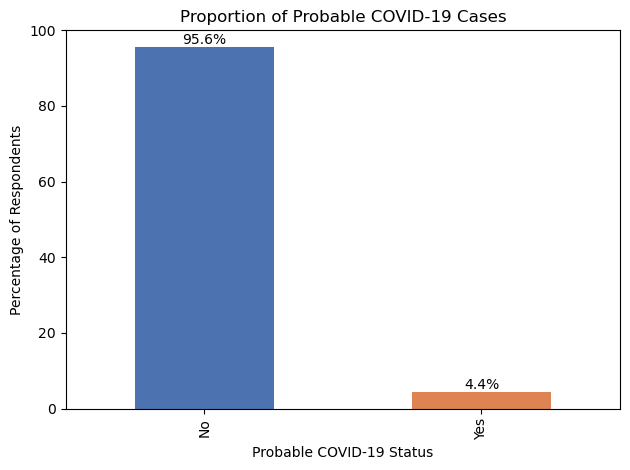

In [48]:
#“What proportion of survey respondents met the criteria for a probable COVID-19 case?”
import matplotlib.pyplot as plt

ax = (
    covid_df["probable"]
    .value_counts(normalize=True)   # convert counts to proportions
    .mul(100)                       # convert proportions to percentages
    .plot(kind="bar", color=["#4C72B0", "#DD8452"])
)

plt.title("Proportion of Probable COVID-19 Cases")
plt.xlabel("Probable COVID-19 Status")
plt.ylabel("Percentage of Respondents")
plt.ylim(0, 100)                   # consistent percentage scale

# Add percentage labels on bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


“The majority of respondents did not meet the survey-based criteria for probable COVID-19. This distribution reflects the population-level nature of the survey and the conservative definition of probable case status.”

<Axes: xlabel='any_medical_conditions'>

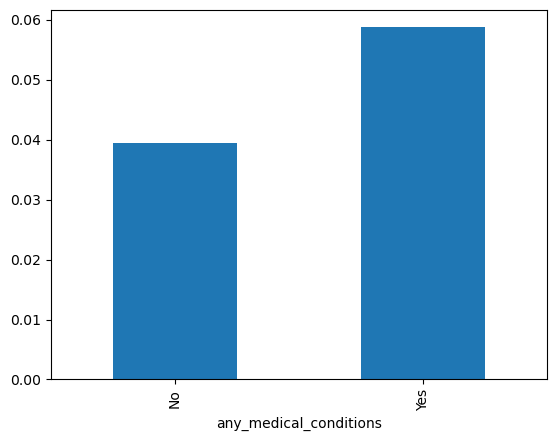

In [49]:
covid_df.groupby("any_medical_conditions")["probable"].apply(
    lambda x: (x == "Yes").mean()
).plot(kind="bar")


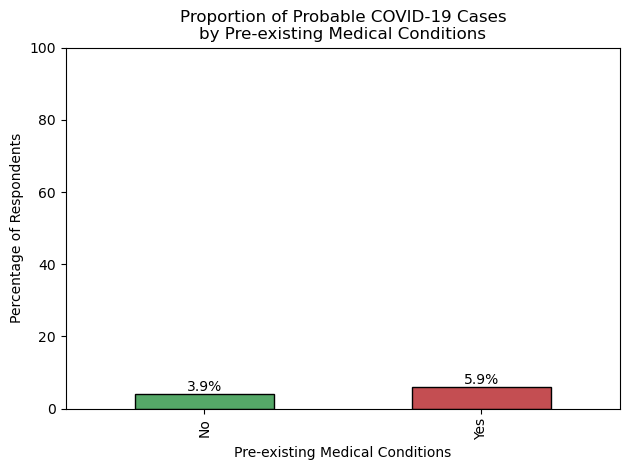

In [50]:
#Are respondents with pre-existing medical conditions more likely to be classified as probable COVID-19 cases than those without medical conditions?
import matplotlib.pyplot as plt

# Calculate proportion of probable cases by medical condition status
prob_by_condition = (
    covid_df.groupby("any_medical_conditions")["probable"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

ax = prob_by_condition.plot(
    kind="bar",
    color=["#55A868", "#C44E52"],
    edgecolor="black"
)

plt.title("Proportion of Probable COVID-19 Cases\nby Pre-existing Medical Conditions")
plt.xlabel("Pre-existing Medical Conditions")
plt.ylabel("Percentage of Respondents")
plt.ylim(0, 100)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


Respondents with pre-existing medical conditions have a higher proportion of probable COVID-19 cases than those without medical conditions.Although most respondents did not meet the criteria for probable COVID-19, those with pre-existing conditions were disproportionately represented among probable cases.
The prevalence of probable COVID-19 was elevated among respondents with underlying medical conditions, consistent with known clinical risk factors.
Key insight:
Underlying medical conditions are associated with a higher likelihood of meeting the criteria for probable COVID-19.

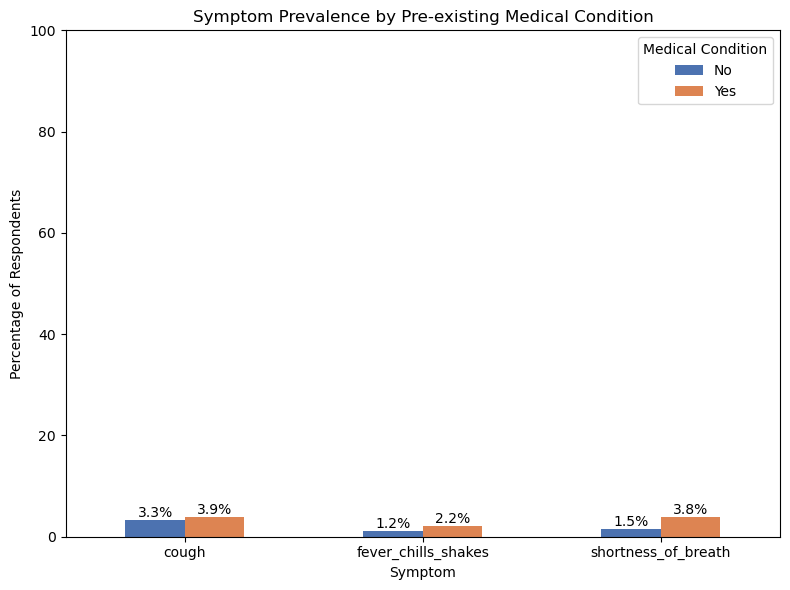

In [51]:
import matplotlib.pyplot as plt

# List of key symptoms
symptoms = ["cough", "fever_chills_shakes", "shortness_of_breath"]

# Calculate % of respondents with each symptom by medical condition
symptom_by_condition = covid_df.groupby("any_medical_conditions")[symptoms].apply(lambda x: (x == "Yes").mean() * 100)

# Plot
ax = symptom_by_condition.T.plot(kind="bar", figsize=(8,6), color=["#4C72B0", "#DD8452"])

plt.title("Symptom Prevalence by Pre-existing Medical Condition")
plt.xlabel("Symptom")
plt.ylabel("Percentage of Respondents")
plt.ylim(0, 100)
plt.legend(title="Medical Condition")
plt.xticks(rotation=0)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()
